# 한국어, 중국어, 영어 예제

실제 문장에서 개체명 인식(NER), 관계 추출(Relation Extraction) 을 수행하고 시각화를 통해 정보추출의 전체 과정을 이해한다.

In [6]:
# 설치 (Colab / Jupyter Notebook)
!pip install spacy transformers torch networkx matplotlib
!python -m spacy download en_core_web_sm
!python -m spacy download zh_core_web_sm
!pip install spacy spacy-stanza kss transformers torch networkx matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 98.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 36.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('zh_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.0/163.0 kB 5.8 MB/s eta 0:00:00
     ━━━

# ① spacy를 활용한 개체명 인식 (Named Entity Recognition, NER)

In [17]:
# =============================
# 🧠 영어 개체명 인식 (NER) 실습 예제
# =============================

import spacy
from spacy import displacy   # 시각화 도구

# 1️⃣ 영어 NER 모델 로드
#    - spaCy에서 기본으로 제공하는 영어 모델 사용
#    - 'en_core_web_sm' : 소형(small) 영어 모델
nlp = spacy.load("en_core_web_sm")

# 2️⃣ 분석할 문장 입력
#    - 문장 안에는 인물(Person), 조직(Organization), 날짜(Date), 장소(Location) 등이 포함됨
text = "Steve Jobs founded Apple in 1976 in California."

# 3️⃣ 모델에 문장 전달 → 분석 수행
doc = nlp(text)

# 4️⃣ 개체명 인식 결과 출력
#    - ent.text : 문장에서 인식된 단어(또는 구)
#    - ent.label_ : 개체 유형(Person, Org, Date 등)
for ent in doc.ents:
    print(f"{ent.text:<15} | {ent.label_}")

# 5️⃣ 개체명 시각화
#    - displaCy.render()를 이용하면 주피터 노트북에서
#      문장 내 엔티티를 색상으로 표시해줌
displacy.render(doc, style="ent", jupyter=True)

Steve Jobs      | PERSON
Apple           | ORG
1976            | DATE
California      | GPE


In [18]:
# =============================
# 🧠 중국어 개체명 인식 (NER) 실습 예제
# =============================

import spacy
from spacy import displacy   # 시각화 도구

# 1️⃣ 중국어 NER 모델 로드
#    - spaCy에서 기본 제공하는 중국어 모델 (zh_core_web_sm)
#    - 품사 분석, 개체명 인식(NER), 의존 구문 분석 기능 포함
nlp_zh = spacy.load("zh_core_web_sm")

# 2️⃣ 분석할 중국어 문장 입력
#    - 문장 안에는 인물(马云), 시간(1999年), 장소(杭州), 조직(阿里巴巴集团)이 포함됨
text_zh = "马云于1999年在杭州创立了阿里巴巴集团。"

# 3️⃣ 모델에 문장 전달 → 자연어 분석 수행
doc_zh = nlp_zh(text_zh)

# 4️⃣ 개체명 인식 결과 출력
#    - ent.text : 문장에서 추출된 개체명 문자열
#    - ent.label_ : 개체 유형 (PER, ORG, LOC, DATE 등)
for ent in doc_zh.ents:
    print(f"{ent.text:<15} | {ent.label_}")

# 5️⃣ 개체명 시각화
#    - displaCy.render()를 이용하면 주피터 노트북에서
#      인식된 개체를 색상별로 하이라이트하여 표시
displacy.render(doc_zh, style="ent", jupyter=True)

马云于             | GPE
1999年           | DATE
杭州              | GPE
阿里巴巴集团          | ORG


# ② 관계 시각화 Demo (Relation Extraction)

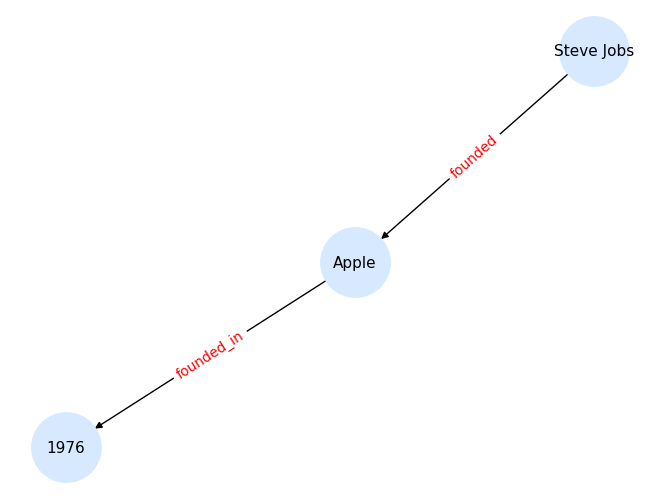

In [19]:
# =============================
# 📊 관계 그래프 시각화 예제 (Relation Graph Demo)
# =============================

import networkx as nx
import matplotlib.pyplot as plt

# 1️⃣ 관계 데이터 정의
#   - (주어, 관계, 목적어)의 형태로 "삼중(triple)" 구조를 만듭니다.
#   - 여기서는 예시로 "Steve Jobs가 Apple을 설립했다"를 표현합니다.
triples = [
    ("Steve Jobs", "founded", "Apple"),
    ("Apple", "founded_in", "1976")
]

# 2️⃣ 방향 그래프(Directed Graph) 생성
#   - networkx의 DiGraph()는 화살표 방향이 있는 그래프를 만듭니다.
G = nx.DiGraph()

# 3️⃣ 각 관계(triple)를 그래프의 엣지(edge)로 추가
#   - add_edge(출발노드, 도착노드, label=관계명)
for h, r, t in triples:
    G.add_edge(h, t, label=r)

# 4️⃣ 노드의 위치를 자동으로 배치 (spring_layout)
#   - seed 값이 고정되어야 매번 비슷한 모양으로 표시됩니다.
pos = nx.spring_layout(G, seed=42)

# 5️⃣ 노드(개체) 시각화
#   - node_color: 노드 색상
#   - node_size: 노드 크기
#   - font_size: 노드 글자 크기
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2500,
    node_color="#D7E9FF",
    font_size=11
)

# 6️⃣ 관계(엣지) 라벨 표시
#   - 각 화살표 위에 관계 이름(founded, founded_in)을 적습니다.
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_color='red'
)

# 7️⃣ 그래프 출력
#   - plt.show()를 실행하면 노드와 관계가 시각적으로 표시됩니다.
plt.show()

# ③ Transformers 기반 영어 NER (Hugging Face)

In [20]:
# =============================
# 🤖 사전학습(Pretrained) 언어모델을 이용한 개체명 인식 (NER)
# =============================

from transformers import pipeline  # 🤗 Transformers의 고수준 API (Pipeline) 불러오기

# 1️⃣ NER 파이프라인 생성
#   - "ner": 개체명 인식(Named Entity Recognition) 작업
#   - model="dslim/bert-base-NER": 영어 NER용 사전학습된 BERT 모델
#   - aggregation_strategy="simple": 같은 개체 토큰을 하나로 합침 (예: "Steve" + "Jobs" → "Steve Jobs")
ner = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple")

# 2️⃣ 분석할 문장 입력
#   - 예시 문장에는 인물(Person), 조직(Organization), 날짜(Date), 장소(Location)이 포함되어 있음
#   - 다른 문장 예시: “Elon Musk acquired Twitter in 2022 for 44 billion dollars.”
text = "Steve Jobs founded Apple in 1976 in California."

# 3️⃣ 모델에 문장 입력 → 개체명 인식 수행
result = ner(text)

# 4️⃣ 결과 출력
#   - r['word'] : 인식된 개체명 문자열
#   - r['entity_group'] : 개체 유형 (PER, ORG, LOC, DATE 등)
#   - r['score'] : 신뢰도(Confidence Score)
print("=== 개체명 인식 결과 ===")
for r in result:
    print(f"{r['word']:<15} | {r['entity_group']:<10} | {r['score']:.3f}")

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


=== 개체명 인식 결과 ===
Steve Jobs      | PER        | 0.999
Apple           | ORG        | 0.999
California      | LOC        | 1.000


# Transformers 기반 한국어 NER (Hugging Face)

In [21]:
# =============================
# 🌐 다국어 개체명 인식 (Multilingual NER) 실습 예제
# =============================

from transformers import pipeline  # 🤗 Transformers의 고수준 API (Pipeline) 불러오기

# 1️⃣ NER 파이프라인 생성
#   - "ner": Named Entity Recognition (개체명 인식)
#   - model="Davlan/xlm-roberta-base-ner-hrl"
#       : XLM-RoBERTa 기반 다국어 NER 모델
#         (영어, 중국어, 한국어 등 고자원 언어에서 잘 동작)
#   - aggregation_strategy="simple"
#       : 같은 개체 토큰을 하나로 합침 (예: “이” + “재용” → “이재용”)
ner_multi = pipeline("ner", model="Davlan/xlm-roberta-base-ner-hrl", aggregation_strategy="simple")

# 2️⃣ 분석할 문장 입력
#   - 한국어 문장 예시
#   - 인물(PER), 날짜(DATE), 장소(LOC), 조직(ORG) 등이 포함되어 있음
sent_ko = "이재용은 2025년에 서울에서 삼성전자 신제품을 발표했다."

# 3️⃣ 모델에 문장 입력 → 개체명 인식 수행
result = ner_multi(sent_ko)

# 4️⃣ 결과 출력
#   - r['word'] : 인식된 단어 또는 구
#   - r['entity_group'] : 개체 유형 (PER, ORG, LOC, DATE 등)
#   - r['score'] : 인식 신뢰도(Confidence Score)
print("=== 한국어 개체명 인식 결과 ===")
for r in result:
    print(f"{r['word']:<12} | {r['entity_group']:<8} | {r['score']:.3f}")

Device set to use cpu


=== 한국어 개체명 인식 결과 ===
이재용          | PER      | 0.982
서울           | LOC      | 0.994
삼성전자         | ORG      | 1.000


In [22]:
from transformers import pipeline
from spacy.tokens import Span

text = "이재용은 2025년에 서울에서 삼성전자 신제품을 발표했다."

# 1) 한국어 문장 분석(토큰화/품사/의존)
doc = nlp_ko(text)

# 2) 다국어 NER 파이프라인 (XLM-R 기반)
ner_multi = pipeline("ner", model="Davlan/xlm-roberta-base-ner-hrl",
                     aggregation_strategy="simple")

# 3) 트랜스포머 NER 실행 (문자오프셋 기반 결과)
ners = ner_multi(text)
print("[NER 결과(raw)]")
for r in ners:
    print(r)

# 4) spaCy Doc에 엔티티 주입(문자 offset → Span)
label_map = {"PER":"PERSON","ORG":"ORG","LOC":"GPE","DATE":"DATE"}  # 표시 라벨 정리(선택)
spans = []
for r in ners:
    start, end = r["start"], r["end"]
    label = label_map.get(r["entity_group"], r["entity_group"])
    span = doc.char_span(start, end, label=label, alignment_mode="contract")
    if span is not None:
        spans.append(span)

# 기존 엔티티를 대체하여 시각화용으로 설정
doc.set_ents(spans, default="unmodified")

# 5) 한글 하이라이트 시각화
displacy.render(doc, style="ent", jupyter=True)


NameError: name 'nlp_ko' is not defined